In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



### Load the dataset

In [2]:
df = pd.read_excel('KPC_Pipeline_Operations_2500_Rows.xlsx')
df.head()

,Record_ID,Date,Pipeline_ID,Station,Product_Type,Volume_Transported_Ltrs,Pressure_Level_Bar,Downtime_Hours,Leakage_Incidents,Maintenance_Cost_KES,Fuel_Loss_Ltrs,Revenue_KES,Technician_Count,Temperature_C,Risk_Level
0,1,2025-11-23,KPC-05,Nairobi,Petrol,37624,113,19,2,166105,922,998991,12,40,High
1,2,2025-05-28,KPC-03,Nairobi,Kerosene,105152,103,9,2,113163,258,2619208,10,38,Low
2,3,2024-11-07,KPC-03,Nakuru,Kerosene,17236,104,2,2,91625,198,530485,7,41,Low
3,4,2024-01-28,KPC-03,Mombasa,Jet Fuel,74353,119,12,1,100592,381,1629639,11,36,Medium
4,5,2024-11-28,KPC-03,Nairobi,Jet Fuel,57187,67,8,2,102662,328,1740986,8,43,High


### Data Understanding

In [3]:
df.shape

(2500, 15)

In [4]:
# columns
df.columns

Index(['Record_ID', 'Date', 'Pipeline_ID', 'Station', 'Product_Type',
       'Volume_Transported_Ltrs', 'Pressure_Level_Bar', 'Downtime_Hours',
       'Leakage_Incidents', 'Maintenance_Cost_KES', 'Fuel_Loss_Ltrs',
       'Revenue_KES', 'Technician_Count', 'Temperature_C', 'Risk_Level'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Record_ID                2500 non-null   int64         
 1   Date                     2500 non-null   datetime64[us]
 2   Pipeline_ID              2500 non-null   str           
 3   Station                  2500 non-null   str           
 4   Product_Type             2500 non-null   str           
 5   Volume_Transported_Ltrs  2500 non-null   int64         
 6   Pressure_Level_Bar       2500 non-null   int64         
 7   Downtime_Hours           2500 non-null   int64         
 8   Leakage_Incidents        2500 non-null   int64         
 9   Maintenance_Cost_KES     2500 non-null   int64         
 10  Fuel_Loss_Ltrs           2500 non-null   int64         
 11  Revenue_KES              2500 non-null   int64         
 12  Technician_Count         2500 non-null   int6

### Summary statistics

In [7]:
df.describe()

,Record_ID,Date,Volume_Transported_Ltrs,Pressure_Level_Bar,Downtime_Hours,Leakage_Incidents,Maintenance_Cost_KES,Fuel_Loss_Ltrs,Revenue_KES,Technician_Count,Temperature_C
count,2500.00000,2500,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2.500000e+03,2500.000000,2500.000000
mean,1250.50000,2024-12-30 04:43:58.080000,78983.658800,84.946000,11.916800,2.058800,141042.946800,567.654400,2.172950e+06,8.370800,32.682400
min,1.00000,2024-01-01 00:00:00,10071.000000,50.000000,0.000000,0.000000,12282.000000,0.000000,2.181680e+05,2.000000,20.000000
25%,625.75000,2024-06-29 00:00:00,44896.750000,67.000000,6.000000,1.000000,106165.250000,166.750000,1.180017e+06,5.000000,26.000000
50%,1250.50000,2025-01-02 12:00:00,79122.000000,85.000000,12.000000,2.000000,140458.000000,436.000000,2.130935e+06,8.000000,33.000000
75%,1875.25000,2025-06-30 00:00:00,112964.000000,103.000000,18.000000,3.000000,176793.250000,879.250000,3.019380e+06,12.000000,39.000000
max,2500.00000,2025-12-31 00:00:00,149945.000000,120.000000,24.000000,4.000000,266569.000000,2000.000000,5.207531e+06,15.000000,45.000000
std,721.83216,NaN,39804.720096,20.761992,7.146685,1.390581,50611.473279,505.837926,1.163704e+06,4.043643,7.577526


### Missing Values

In [9]:
df.isnull().sum()

Record_ID                  0
Date                       0
Pipeline_ID                0
Station                    0
Product_Type               0
Volume_Transported_Ltrs    0
Pressure_Level_Bar         0
Downtime_Hours             0
Leakage_Incidents          0
Maintenance_Cost_KES       0
Fuel_Loss_Ltrs             0
Revenue_KES                0
Technician_Count           0
Temperature_C              0
Risk_Level                 0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100

Record_ID                  0.0
Date                       0.0
Pipeline_ID                0.0
Station                    0.0
Product_Type               0.0
Volume_Transported_Ltrs    0.0
Pressure_Level_Bar         0.0
Downtime_Hours             0.0
Leakage_Incidents          0.0
Maintenance_Cost_KES       0.0
Fuel_Loss_Ltrs             0.0
Revenue_KES                0.0
Technician_Count           0.0
Temperature_C              0.0
Risk_Level                 0.0
dtype: float64

### Duplicated records

In [11]:
df.duplicated().sum()

np.int64(0)

#### Numerical Variable distributions

In [13]:
num_cols=df.select_dtypes(include=np.number).columns
num_cols.tolist()

['Record_ID',
 'Volume_Transported_Ltrs',
 'Pressure_Level_Bar',
 'Downtime_Hours',
 'Leakage_Incidents',
 'Maintenance_Cost_KES',
 'Fuel_Loss_Ltrs',
 'Revenue_KES',
 'Technician_Count',
 'Temperature_C']

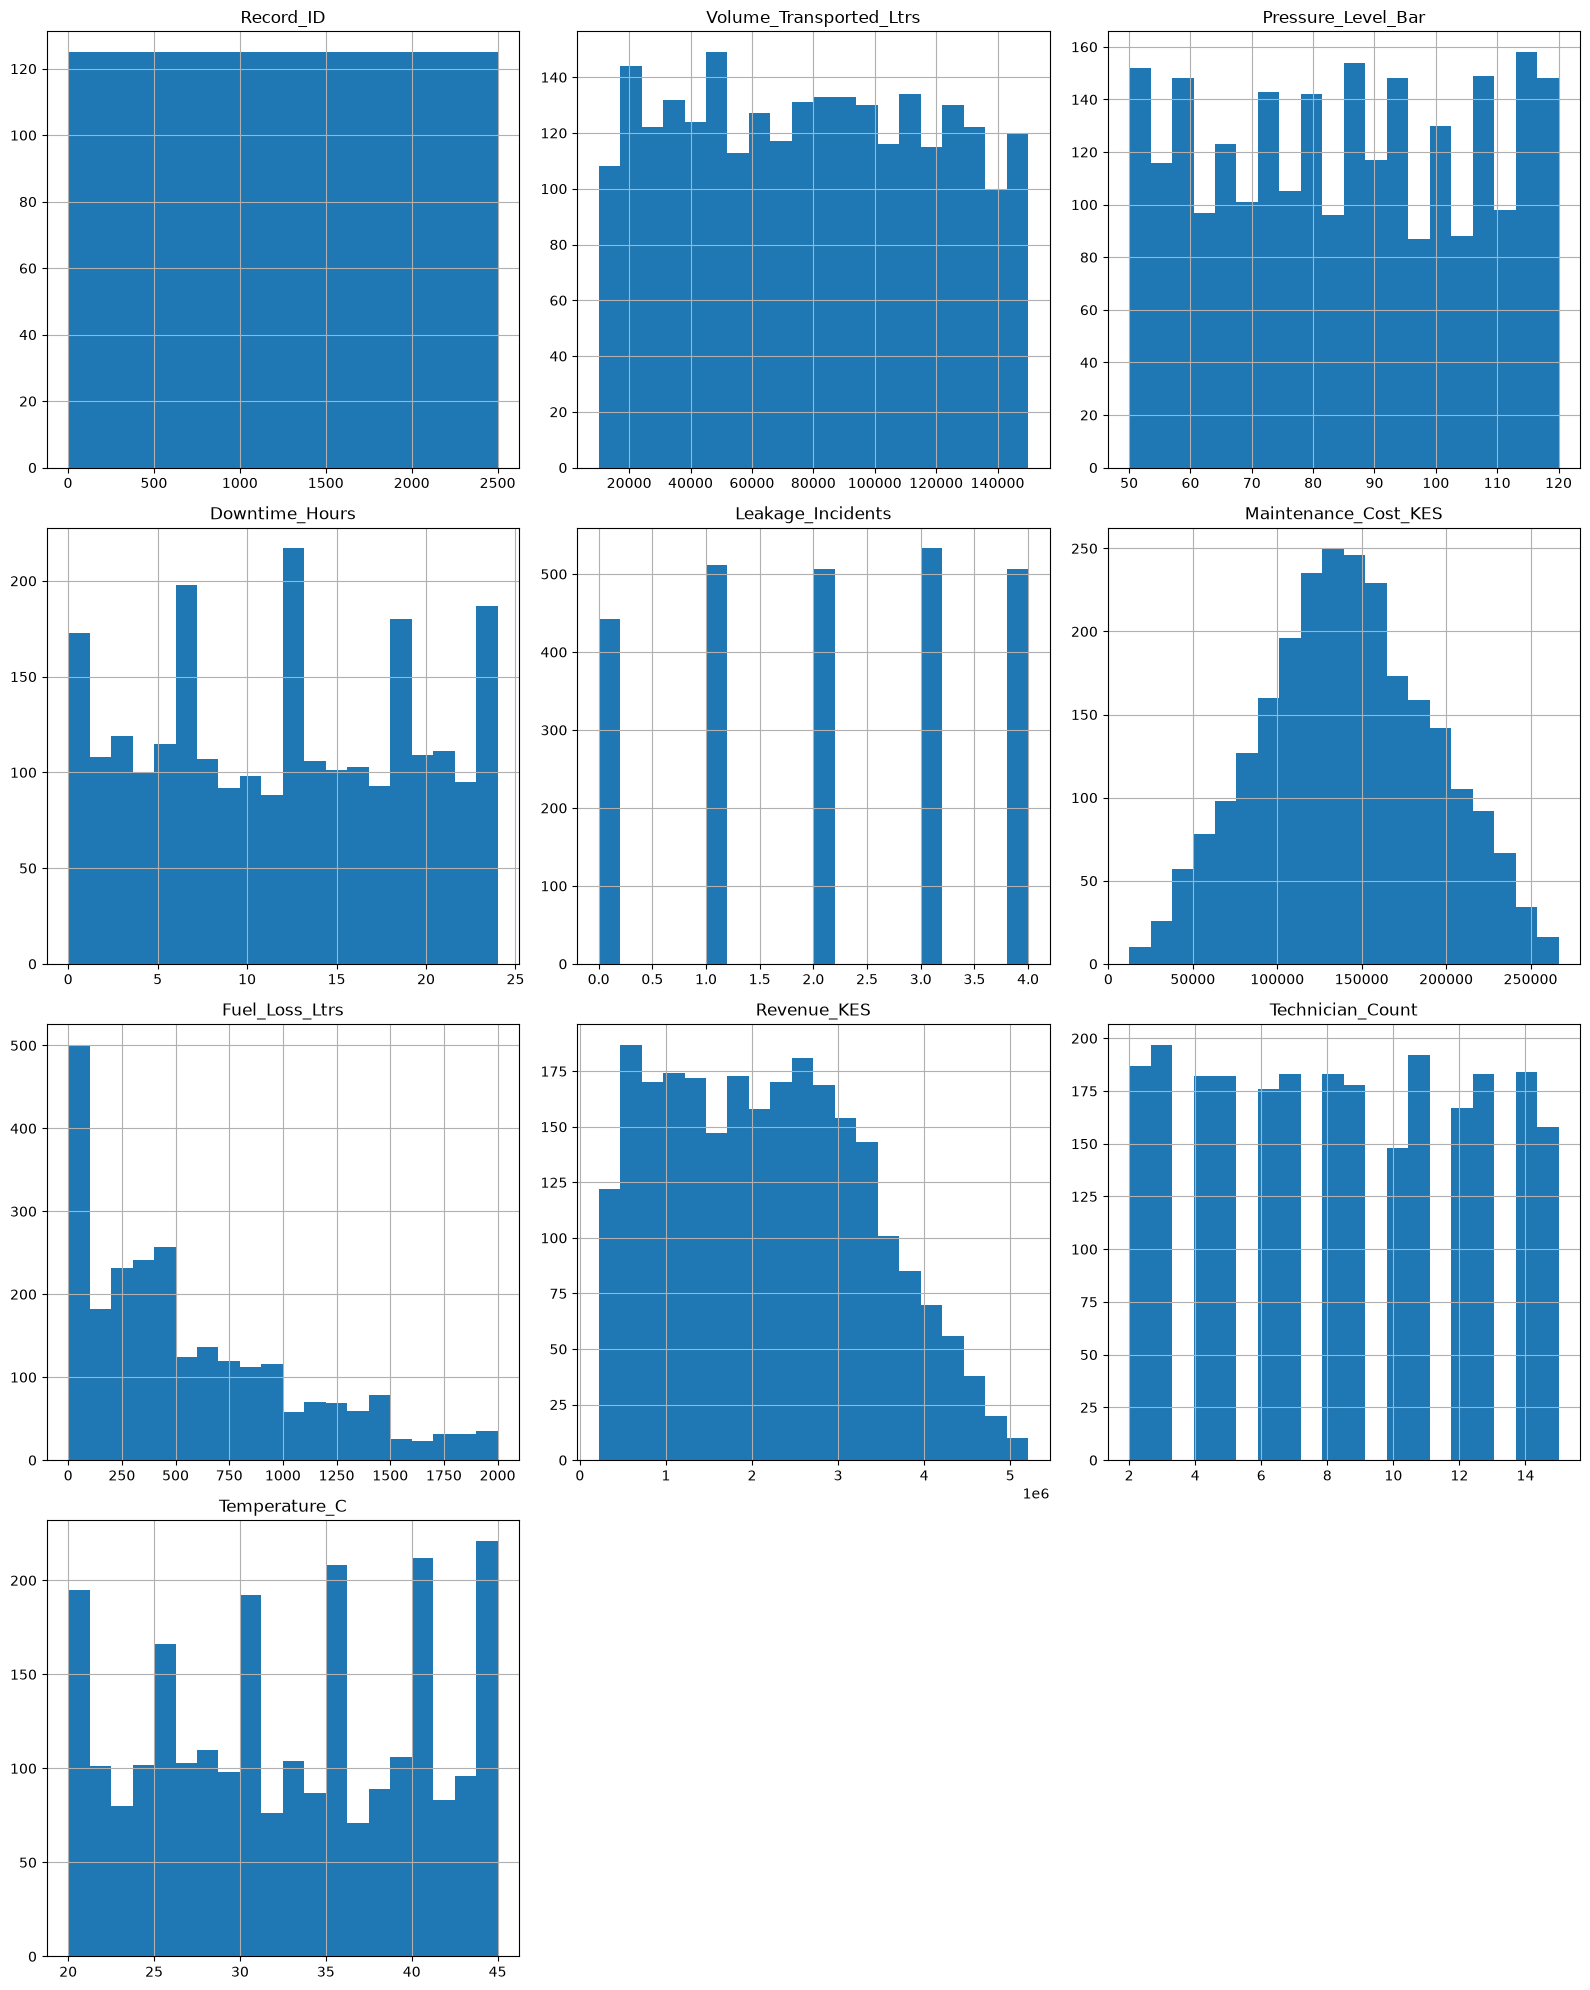

In [25]:
df[num_cols].hist(
    figsize=(16,20),
    bins=20
)
plt.tight_layout()
plt.show()

### EDA

#### Unique values

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n {col}")
    print(df[col].unique())


 Pipeline_ID
<StringArray>
['KPC-05', 'KPC-03', 'KPC-02', 'KPC-01', 'KPC-04']
Length: 5, dtype: str

 Station
<StringArray>
['Nairobi', 'Nakuru', 'Mombasa', 'Eldoret', 'Kisumu']
Length: 5, dtype: str

 Product_Type
<StringArray>
['Petrol', 'Kerosene', 'Jet Fuel', 'Diesel']
Length: 4, dtype: str

 Risk_Level
<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str


C:\Users\hp\AppData\Local\Temp\ipykernel_17480\609101092.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


#### Date analysis

In [17]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [18]:
df['Date'].min(), df['Date'].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [20]:
df['Year']=df['Date'].dt.year

In [21]:
df['Month'] = df['Date'].dt.month

In [22]:
df['Date'] = df['Date'].dt.month_name()

##### Target variable distribution

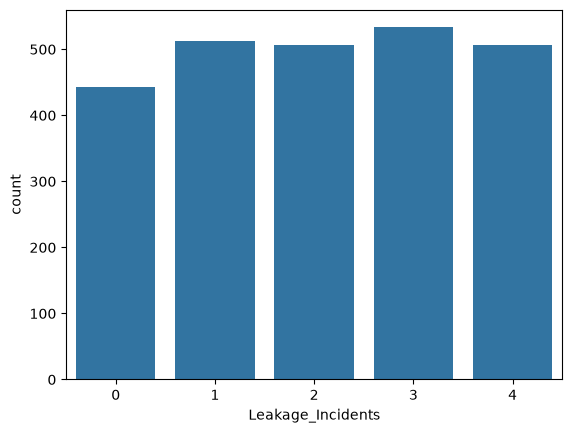

In [14]:
sns.countplot(x='Leakage_Incidents',data=df)
plt.show()

How many records do we have for each Station?

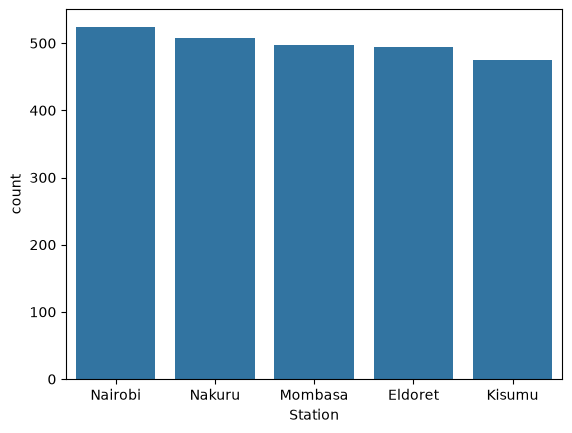

In [26]:
sns.countplot(data=df, x='Station')
plt.show()

How many operations are High, Medium and Low risk levels?

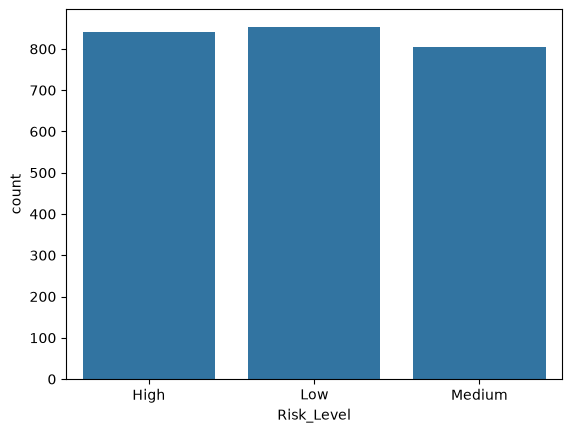

In [28]:
sns.countplot(data=df, x='Risk_Level')
plt.show()

What pressure levels are most common?

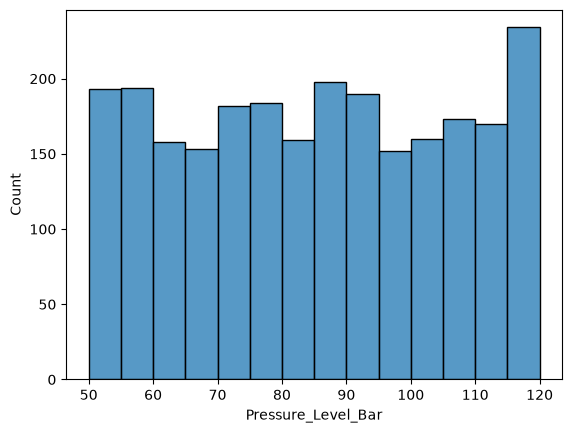

In [33]:
sns.histplot(data=df, x='Pressure_Level_Bar', )
plt.show()

What is the distribuion of the downtime hours?

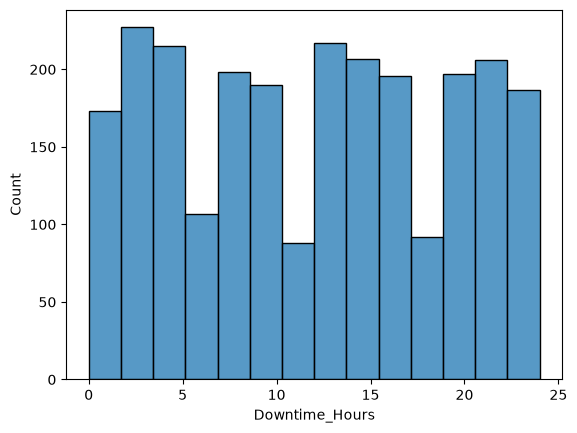

In [34]:
sns.histplot(data=df, x='Downtime_Hours', )
plt.show()

How much revenue does each Station generate?

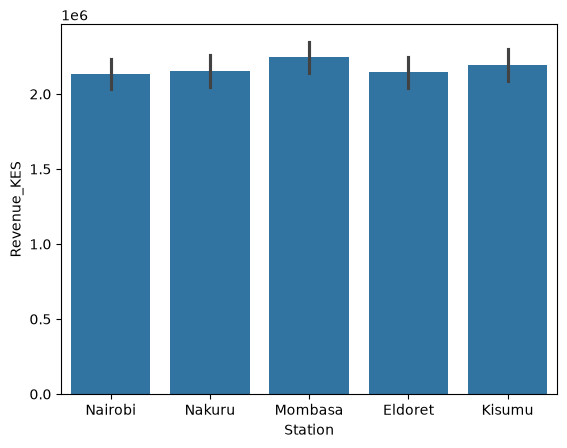

In [35]:
sns.barplot(data=df, x='Station', y='Revenue_KES')
plt.show()

What is the distribution of downtime hours among stations?

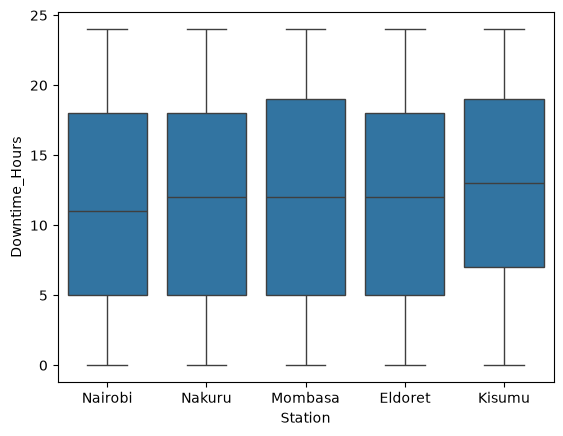

In [36]:
sns.boxplot(data=df, x='Station', y='Downtime_Hours')
plt.show()

Revenue by Station

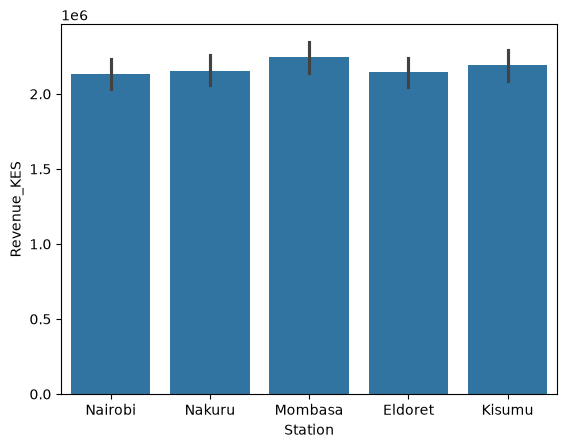

In [50]:
sns.barplot(data=df, x='Station', y='Revenue_KES')
plt.show()

Fuel loss by station

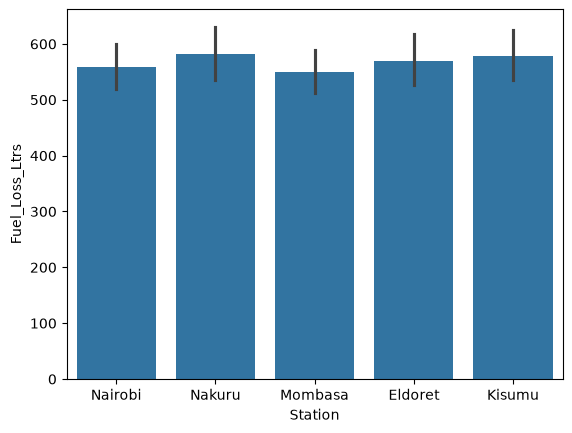

In [51]:
sns.barplot(data=df, x='Station',y='Fuel_Loss_Ltrs')
plt.show()

Is there a relationship between Leakage incidents and pressure levels?

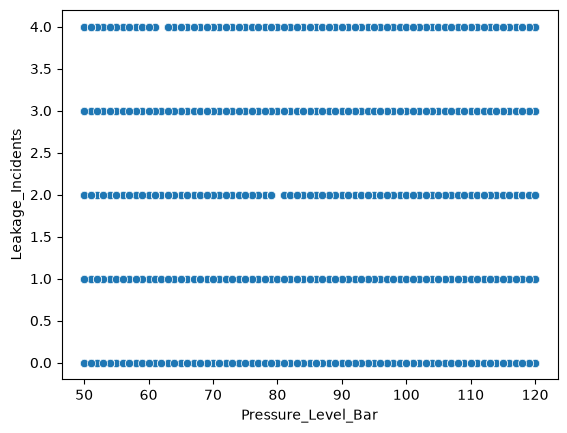

In [56]:
sns.scatterplot(data=df, y='Leakage_Incidents', x='Pressure_Level_Bar')
plt.show()

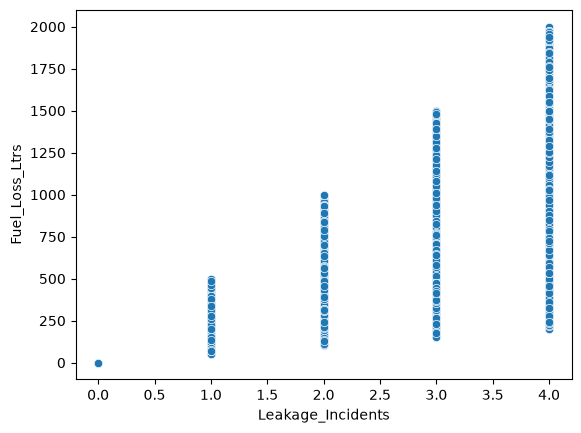

In [42]:
sns.scatterplot(
    data=df,
    x='Leakage_Incidents',
    y='Fuel_Loss_Ltrs'
)

plt.show()

Within each stations, howm many records are high, medium and low risk?

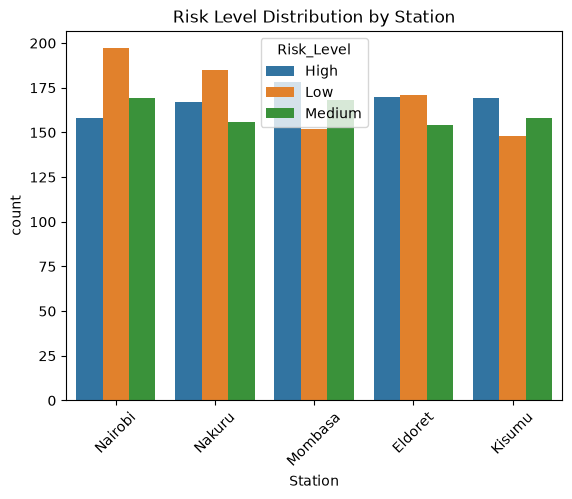

In [45]:
sns.countplot(data=df, x='Station', hue='Risk_Level')
plt.title('Risk Level Distribution by Station')

plt.xticks(rotation=45)
plt.show()

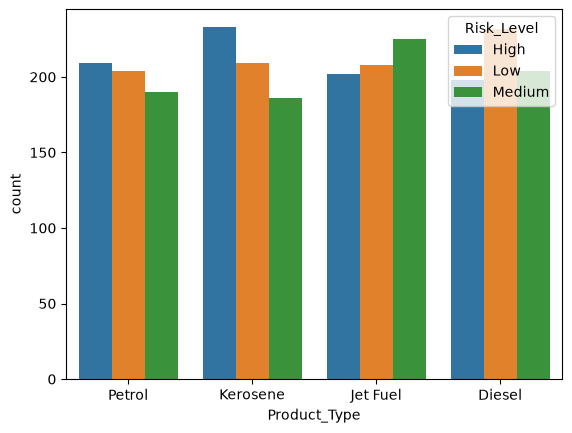

In [84]:
sns.countplot(data=df, x='Product_Type', hue='Risk_Level')
plt.show()

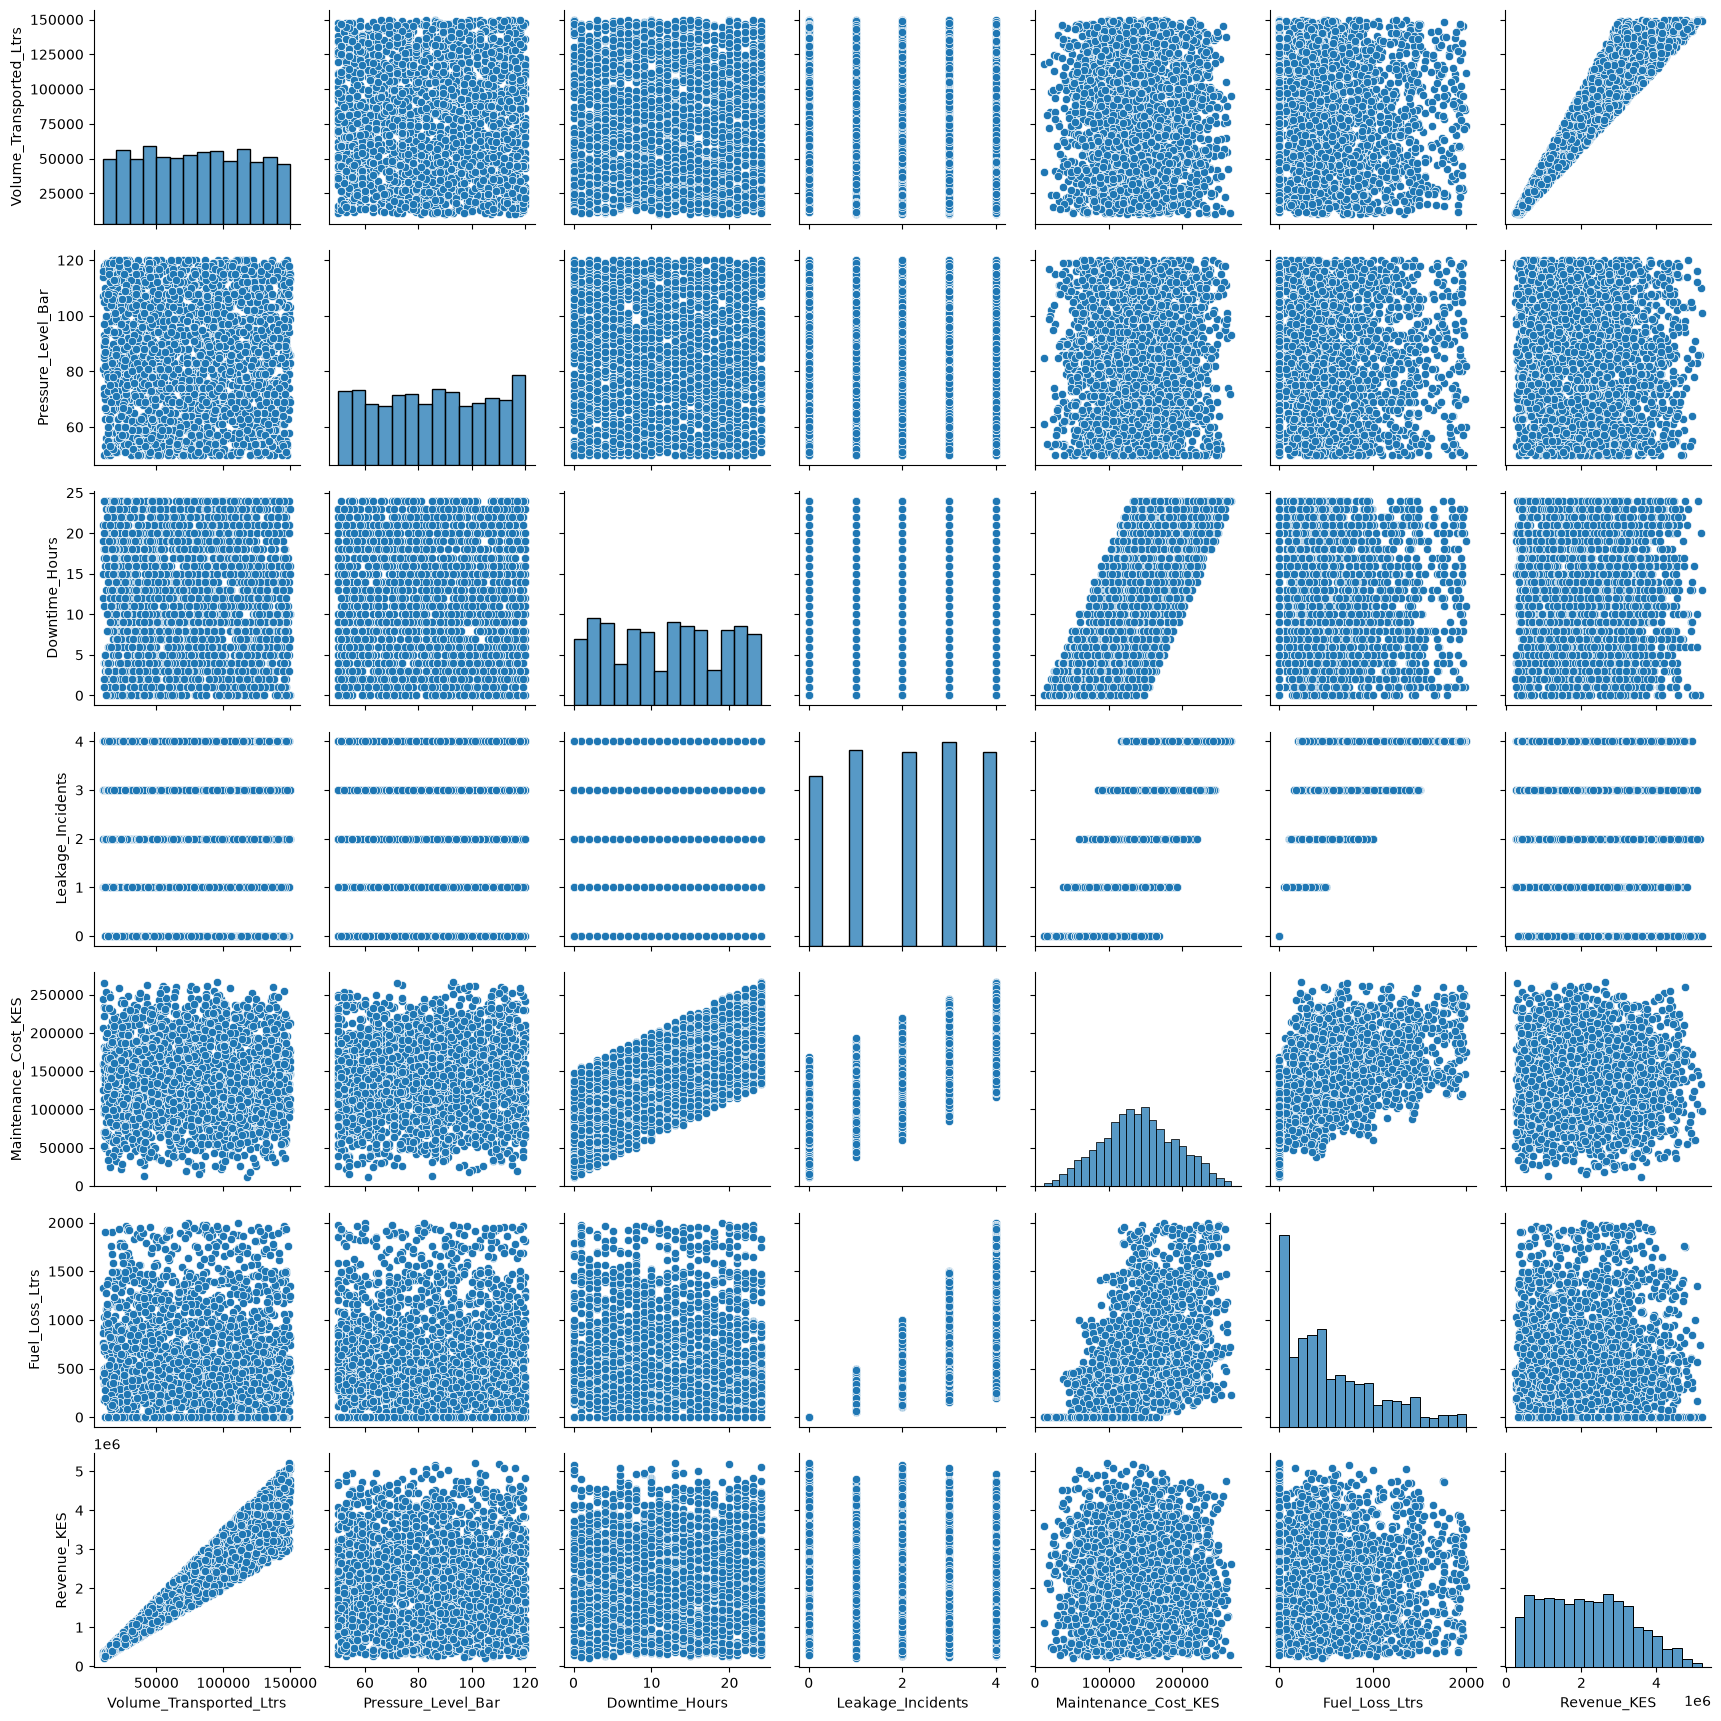

In [47]:
selected_cols = [
    'Volume_Transported_Ltrs',
    'Pressure_Level_Bar',
    'Downtime_Hours',
    'Leakage_Incidents',
    'Maintenance_Cost_KES',
    'Fuel_Loss_Ltrs',
    'Revenue_KES'
]

sns.pairplot(df[selected_cols])

plt.show()

How does the pressure distribution differ by risk level?

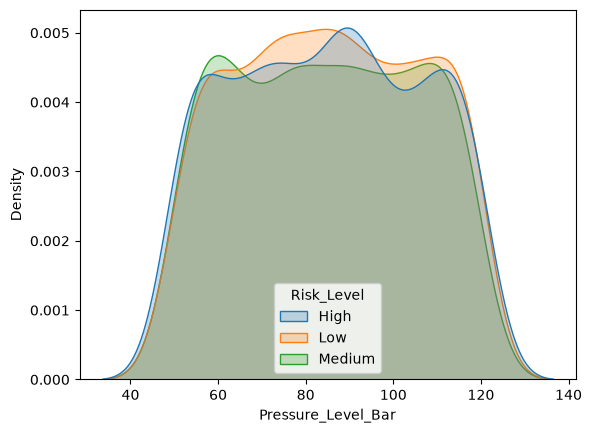

In [48]:
sns.kdeplot(data=df, x='Pressure_Level_Bar', hue='Risk_Level', fill=True)
plt.show()

In [61]:
df['Month'].head()

0    11
1     5
2    11
3     1
4    11
Name: Month, dtype: int32

In [70]:
monthly_revenue = df.groupby('Month')['Revenue_KES'].sum().reset_index()
yearly_revenue=df.groupby('Year')['Revenue_KES'].sum().reset_index()

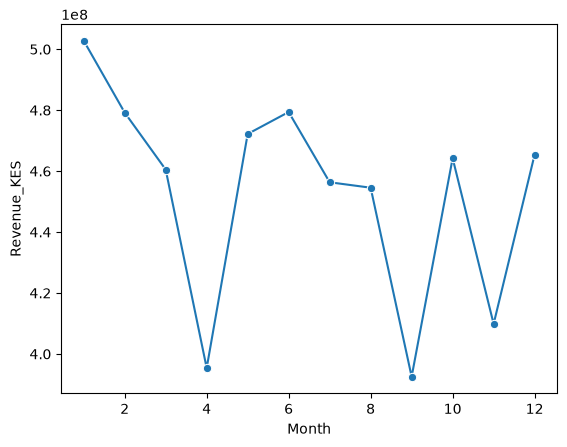

In [74]:
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue_KES', marker='o')
plt.show()

In [78]:
df[['Date', 'Year', 'Revenue_KES']].head()

,Date,Year,Revenue_KES
0,November,2025,998991
1,May,2025,2619208
2,November,2024,530485
3,January,2024,1629639
4,November,2024,1740986


Correlation heatmap

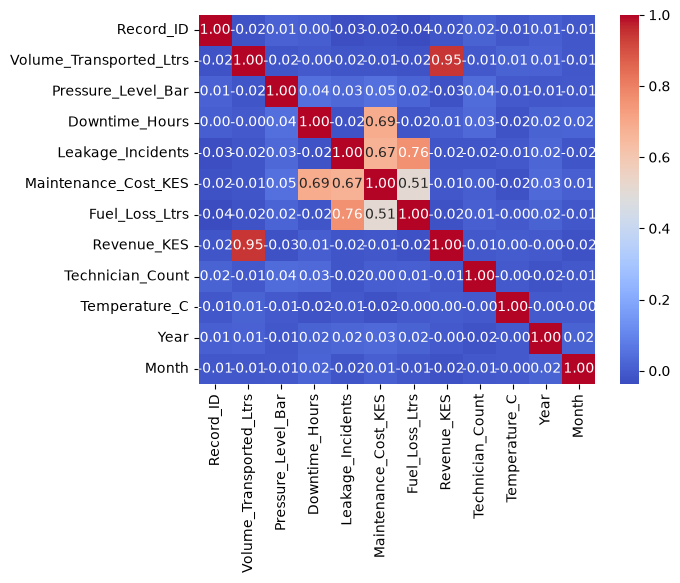

In [49]:
corr= df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [58]:
df.head()

,Record_ID,Date,Pipeline_ID,Station,Product_Type,Volume_Transported_Ltrs,Pressure_Level_Bar,Downtime_Hours,Leakage_Incidents,Maintenance_Cost_KES,Fuel_Loss_Ltrs,Revenue_KES,Technician_Count,Temperature_C,Risk_Level,Year,Month
0,1,November,KPC-05,Nairobi,Petrol,37624,113,19,2,166105,922,998991,12,40,High,2025,11
1,2,May,KPC-03,Nairobi,Kerosene,105152,103,9,2,113163,258,2619208,10,38,Low,2025,5
2,3,November,KPC-03,Nakuru,Kerosene,17236,104,2,2,91625,198,530485,7,41,Low,2024,11
3,4,January,KPC-03,Mombasa,Jet Fuel,74353,119,12,1,100592,381,1629639,11,36,Medium,2024,1
4,5,November,KPC-03,Nairobi,Jet Fuel,57187,67,8,2,102662,328,1740986,8,43,High,2024,11
